In [37]:
import pandas as pd
from sentence_transformers import SentenceTransformer
import umap
import plotly.graph_objects as go
from scipy.spatial import KDTree
import torch

In [38]:
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    device = "cuda"
else:
    print("No GPU found, using CPU.")
    device = "cpu"

Using GPU: NVIDIA GeForce RTX 4080 SUPER


In [39]:
df = pd.read_csv("data/raw/movies.csv")
df.head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


In [40]:
list(df.columns)

['names',
 'date_x',
 'score',
 'genre',
 'overview',
 'crew',
 'orig_title',
 'status',
 'orig_lang',
 'budget_x',
 'revenue',
 'country']

In [41]:
placeholder_text = "We don't have an overview translated in English. Help us expand our database by adding one."
df = df[df["overview"] != placeholder_text]

df["genre"] = df["genre"].fillna("Unknown")

duplicate_cols = ["names", "date_x"]

df = df.groupby(duplicate_cols).agg({
    "score": "mean",              # average scores
    "genre": "first",             # keep first genre string
    "overview": "first",          # keep first overview
    "crew": "first",              # keep first crew info
    "orig_title": "first",        # keep original title
    "status": "first",            # keep first status
    "orig_lang": "first",         # keep original language
    "budget_x": "sum",            # sum budgets
    "revenue": "sum",             # sum revenues
    "country": "first"            # keep first country
}).reset_index()

<Axes: >

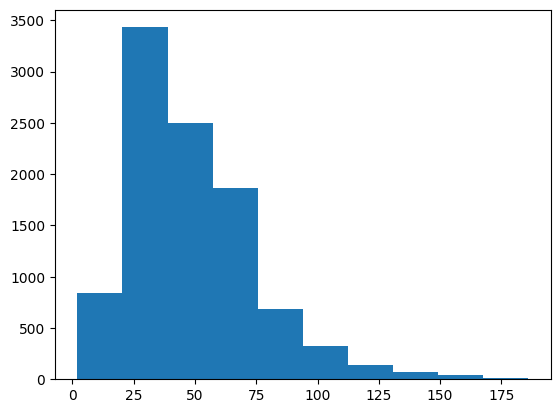

In [42]:
lens = df["overview"].apply(str.split).apply(len)
lens.hist(grid=False)

In [43]:

def textify_movie(row):
    def clean(val):
        if pd.isna(val) or val == '':
            return "Unknown"
        return str(val)

    # Grab the goods
    name = clean(row.get('names'))
    date = clean(row.get('date_x'))
    score = clean(row.get('score'))
    genres = clean(row.get('genre'))
    overview = clean(row.get('overview'))
    crew = clean(row.get('crew'))
    lang = clean(row.get('orig_lang'))
    budget = clean(row.get('budget_x'))
    rev = clean(row.get('revenue'))
    country = clean(row.get('country'))

    # Assemble the mega-string
    text = f"Title: {name}. Released in {date}, this {country} film is primarily in {lang}. "
    text += f"It falls under the {genres} genre. "
    text += f"It holds a rating of {score}/100. "
    text += f"Financially, it had a budget of ${budget} and made ${rev} in revenue. "
    text += f"Plot overview: {overview} "
    text += f"Key crew members include: {crew}."

    return text

df['content'] = df.apply(textify_movie, axis=1)

In [44]:
model = SentenceTransformer("BAAI/bge-small-en-v1.5")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5820.91it/s]
BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [45]:
embeddings = model.encode(
    df["content"].tolist(), 
    device=device,
    show_progress_bar=True,
    normalize_embeddings=True
)

Batches: 100%|██████████| 310/310 [00:10<00:00, 29.83it/s]


In [46]:
reducer = umap.UMAP(
    n_components=3,
    n_neighbors=30,
    min_dist=0.1,
    metric='cosine',
    #random_state=42     # Uncomment for reproducibility, currently left out for speed
)
coords = reducer.fit_transform(embeddings)

In [47]:
coords.shape

(9910, 3)

In [48]:
# Map genres to integers
genre_to_num = {g: i for i, g in enumerate(df["genre"].unique())}
color_nums = df["genre"].map(genre_to_num)

# Create 3D scatter using Scatter3d for better control
fig = go.Figure(
    go.Scatter3d(
        x=coords[:, 0],
        y=coords[:, 1],
        z=coords[:, 2],
        mode='markers',  # ONLY markers
        marker=dict(
            size=2,        # small markers
            opacity=0.8,
            color=color_nums,  # color by genre
        ),
        text=df["names"],  # hover text
    )
)

# Layout settings
fig.update_layout(
    width=1200,
    height=800,
    scene=dict(
        aspectmode='data'
    ),
    template="plotly_dark",
)

fig.show()

In [49]:
df[["x", "y", "z"]] = coords
coords

array([[-0.1395392,  8.799433 , 11.476146 ],
       [-2.8588872, 13.741905 ,  6.8414416],
       [-4.3924375, 13.272971 ,  9.368638 ],
       ...,
       [-4.1288805, 11.988097 ,  8.709271 ],
       [-1.3574696, 10.081255 , 10.258875 ],
       [-1.1043061,  7.875279 ,  8.553743 ]],
      shape=(9910, 3), dtype=float32)

In [50]:
tree = KDTree(coords)

In [51]:
def get_closest_movies(movie_name, df, tree, n=5):
    if movie_name not in df['names'].values:
        return "Movie not found, check your spelling."

    idx = df[df['names'] == movie_name].index[0]
    target_xyz = df.loc[idx, ['x', 'y', 'z']].values

    distances, indices = tree.query(target_xyz, k=n + 1)

    # skipping the first one, which is the reference movie
    neighbor_indices = indices[1:]

    return df.iloc[neighbor_indices]

In [52]:
get_closest_movies("Tenet", df, tree).head()

,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country,content,x,y,z
6112,Riddick,09/12/2013,63.0,"Science Fiction, Action, Thriller",Betrayed by his own kind and left for dead on ...,"Vin Diesel, Riddick, Matt Nable, Colonel R. ""B...",Riddick,Released,English,38000000.0,94763758.0,AU,"Title: Riddick. Released in 09/12/2013 , this ...",-4.722449,12.409891,8.775087
742,Austin Powers in Goldmember,09/19/2002,60.0,"Comedy, Crime, Science Fiction",The world's most shagadelic spy continues his ...,"Mike Myers, Austin Powers / Dr. Evil / Goldmem...",Austin Powers in Goldmember,Released,English,63000000.0,296338663.0,AU,Title: Austin Powers in Goldmember. Released i...,-4.786783,12.448718,8.845567
1708,Coma,11/21/2020,63.0,"Science Fiction, Adventure, Action",A young and talented architect comes to his se...,"Rinal Mukhametov, Viktor, architect, Anton Pam...",Кома,Released,Russian,4000000.0,2363584.0,AU,"Title: Coma. Released in 11/21/2020 , this AU ...",-4.692012,12.304678,8.761844
9155,"Tomorrow, When the War Began",08/08/2010,62.0,"Action, Adventure, Drama","Ellie Linton, a teen from an Australian coasta...","Caitlin Stasey, Ellie Linton, Rachel Hurd-Wood...","Tomorrow, When the War Began",Released,English,27000000.0,16504936.0,AU,"Title: Tomorrow, When the War Began. Released ...",-4.767459,12.278211,8.763423
7999,The Imitation Game,12/19/2014,80.0,"History, Drama, Thriller, War",Based on the real life story of legendary cryp...,"Benedict Cumberbatch, Alan Turing, Keira Knigh...",The Imitation Game,Released,English,15000000.0,227328585.0,AU,Title: The Imitation Game. Released in 12/19/2...,-4.700642,12.442198,8.895509


In [53]:
df.to_csv("data/processed/with_embeddings.csv")